In [31]:
#EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
path = '/content/drive/My Drive/DS 4002/Project 1/book_summaries_10k(in).csv' # Placeholder, please adjust
book_df = pd.read_csv(path)
#cleaning and reducing data frame to the correct columns
book_df = book_df[['Book Title', 'Genre', 'Synopsis']]
display(book_df.head(10))

/tmp/ipykernel_3104/2904277315.py:2: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162) have mixed types. Specify dtype option on import or set low_memory=False.
  book_df = pd.read_csv(path)


,Book Title,Genre,Synopsis
0,Animal Farm,"Roman à clef, Satire, Children's literature, S...","Old Major, the old boar on the Manor Farm, ca..."
1,A Clockwork Orange,"Science Fiction, Novella, Speculative fiction,...","Alex, a teenager living in near-future Englan..."
2,The Plague,"Existentialism, Fiction, Absurdist fiction, Novel",The text of The Plague is divided into five p...
3,An Enquiry Concerning Human Understanding,NaN,The argument of the Enquiry proceeds by a ser...
4,A Fire Upon the Deep,"Hard science fiction, Science Fiction, Specula...",The novel posits that space around the Milky ...
5,All Quiet on the Western Front,"War novel, Roman à clef","The book tells the story of Paul Bäumer, a Ge..."
6,A Wizard of Earthsea,"Children's literature, Fantasy, Speculative fi...","Ged is a young boy on Gont, one of the larger..."
7,Anyone Can Whistle,NaN,The story is set in an imaginary American tow...
8,Blade Runner 3: Replicant Night,"Science Fiction, Speculative fiction","Living on Mars, Deckard is acting as a consul..."
9,Blade Runner 2: The Edge of Human,"Science Fiction, Speculative fiction",Beginning several months after the events in ...


['Fiction', 'Speculative fiction', 'Science Fiction', 'Novel', 'Fantasy', "Children's literature", 'Mystery', 'Suspense', 'Crime Fiction', 'Historical novel']


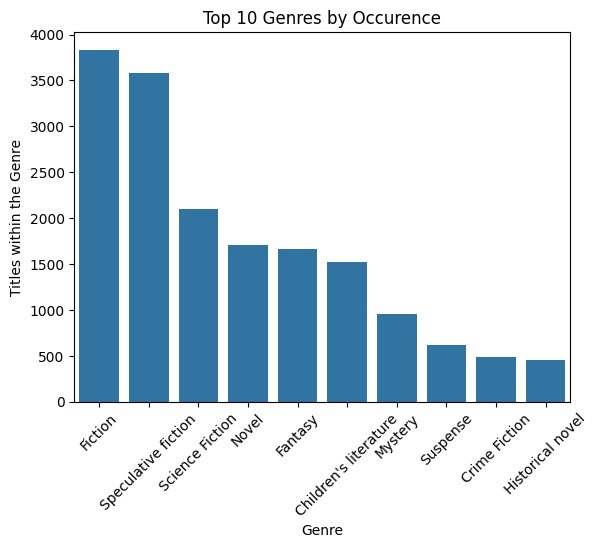

In [37]:
# Counting Genre Occurences. We need to separate listed genres.
book_df['genre_list'] = book_df['Genre'].apply(lambda x: [g.strip() for g in str(x).split(',') if g.strip()])
book_df['num_genres'] = book_df['genre_list'].apply(len)

# Genre counts (removing nan strings as well)
all_genres = [g for sublist in book_df['genre_list'] for g in sublist if g != 'nan']
genre_counts = pd.Series(all_genres).value_counts()
top_10_genres = genre_counts.head(10).index.tolist()
print(top_10_genres)

#Create a chart of genre occurences
plt.figure()
sns.barplot(x=genre_counts.head(10).index, y=genre_counts.head(10).values)
plt.xlabel('Genre')
plt.ylabel('Titles within the Genre')
plt.title('Top 10 Genres by Occurence')
plt.xticks(rotation=45)
plt.show()

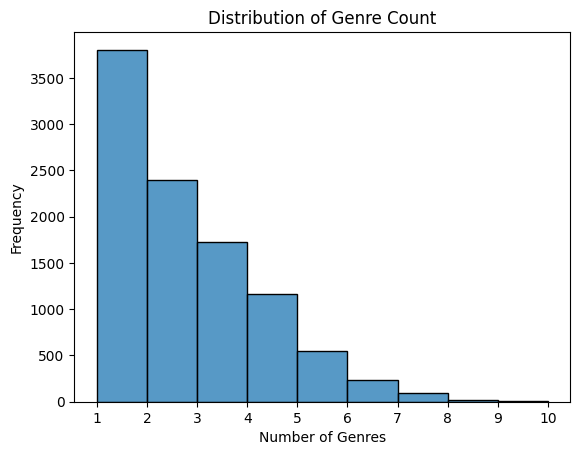

In [35]:
#Limitation: 'Fiction' being counted as a genre. All the top ten genres are fiction genres.
#Many titles will list fiction along with the genre.
#Finding a histogram of genre count distribution

sns.histplot(book_df['num_genres'], bins=range(1, 11))
plt.xlabel('Number of Genres')
plt.ylabel('Frequency')
plt.title('Distribution of Genre Count')
plt.xticks(range(1, 11))
plt.show()

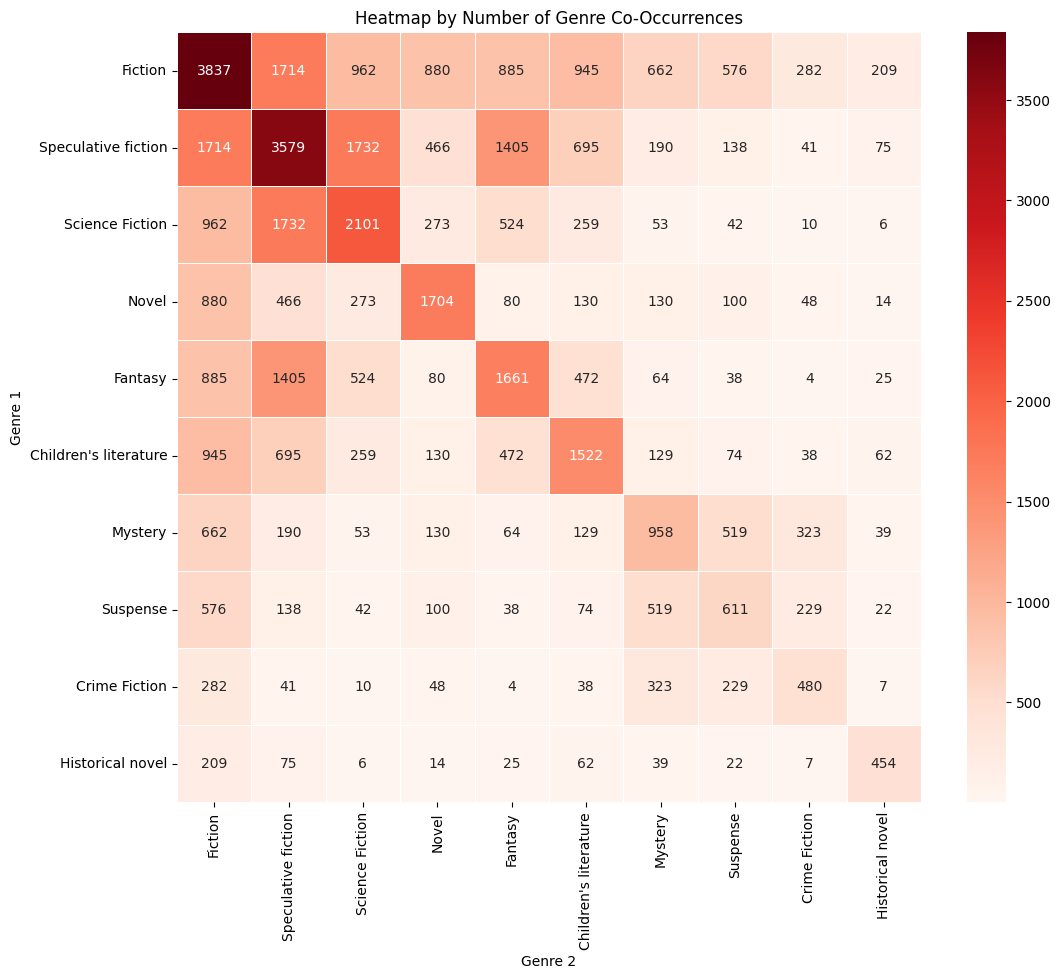

In [38]:
unique_genres = sorted(list(set(g for sublist in book_df['genre_list'] for g in sublist if g != 'nan')))

# Co-occurrence matrix
co_occurrence_matrix = pd.DataFrame(0, index=unique_genres, columns=unique_genres)

for index, row in book_df.iterrows():
    genres_in_book = [g for g in row['genre_list'] if g != 'nan']
    for g1 in genres_in_book:
        for g2 in genres_in_book:
            co_occurrence_matrix.loc[g1, g2] += 1

filtered_matrix = co_occurrence_matrix.loc[top_10_genres, top_10_genres]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_matrix, annot=True, fmt="d", cmap="Reds", linewidths=.5)
plt.title('Heatmap by Number of Genre Co-Occurrences')
plt.xlabel('Genre 2')
plt.ylabel('Genre 1')
plt.show()